# E2 - Analisis exploratorio y preprocesamiento

Accidentes de transito terrestre en zonas urbanas y suburbanas de Sonora.

Este cuaderno corresponde al entregable E2. Su objetivo es documentar y ejecutar la carga, depuracion, preprocesamiento y analisis exploratorio de la base ATUS 2015-2024 para Sonora. No incluye modelos predictivos; esa parte se trabaja en E3.

**Fuente:** ATUS / INEGI  
**Periodo:** 2015-2024  
**Ambito:** Sonora  
**Entrega:** E2

## 1. Instalacion de librerias

Esta celda instala solamente dependencias que pueden faltar en Google Colab. Si ejecutas el notebook localmente y ya tienes las librerias instaladas, no necesita hacer cambios.

In [1]:
import sys
import subprocess
import importlib.util


def ensure_package(import_name, pip_name=None):
    if importlib.util.find_spec(import_name) is None:
        subprocess.check_call([sys.executable, "-m", "pip", "install", pip_name or import_name])


ensure_package("openpyxl")

## 2. Librerias y configuracion

Se importan las librerias de manipulacion de datos y visualizacion. Tambien se ajusta el estilo de graficas para que las salidas sean consistentes.

In [2]:
from pathlib import Path
import os
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 120)
pd.set_option("display.width", 160)
sns.set_theme(style="whitegrid", palette="deep")

## 3. Fuente de datos

El cuaderno puede leer los CSV desde GitHub o desde la carpeta local del repositorio. En modo `auto`, intenta primero GitHub raw, despues jsDelivr y finalmente archivos locales.

In [3]:
DATA_SOURCE = os.getenv("DATA_SOURCE", "auto")  # opciones: "auto", "github", "local"
GITHUB_BRANCH = "master"
GITHUB_RAW_BASE = (
    "https://raw.githubusercontent.com/62636228/prevencion_vial_sonora_Sheeptech/"
    f"{GITHUB_BRANCH}/datos/originales/conjunto_de_datos"
)
GITHUB_RAW_CATALOGS = (
    "https://raw.githubusercontent.com/62636228/prevencion_vial_sonora_Sheeptech/"
    f"{GITHUB_BRANCH}/datos/originales/catalogos"
)
JSDELIVR_BASE = (
    "https://cdn.jsdelivr.net/gh/62636228/prevencion_vial_sonora_Sheeptech@"
    f"{GITHUB_BRANCH}/datos/originales/conjunto_de_datos"
)
JSDELIVR_CATALOGS = (
    "https://cdn.jsdelivr.net/gh/62636228/prevencion_vial_sonora_Sheeptech@"
    f"{GITHUB_BRANCH}/datos/originales/catalogos"
)
LOCAL_DATA_DIR = Path("../datos/originales/conjunto_de_datos")
LOCAL_CATALOG_DIR = Path("../datos/originales/catalogos")

print("Fuentes configuradas")
print("- GitHub raw:", GITHUB_RAW_BASE)
print("- jsDelivr:", JSDELIVR_BASE)
print("- Local:", LOCAL_DATA_DIR.resolve())

Fuentes configuradas
- GitHub raw: https://raw.githubusercontent.com/62636228/prevencion_vial_sonora_Sheeptech/master/datos/originales/conjunto_de_datos
- jsDelivr: https://cdn.jsdelivr.net/gh/62636228/prevencion_vial_sonora_Sheeptech@master/datos/originales/conjunto_de_datos
- Local: C:\Users\felip\OneDrive\Documentos\prevencion_vial_sonora_Sheeptech\datos\originales\conjunto_de_datos


## 4. Carga de datos ATUS 2015-2024

Se cargan los archivos anuales, se filtra Sonora con la clave de entidad `26` y se agrega el catalogo municipal para obtener el nombre del municipio.

In [4]:
YEARS = list(range(2015, 2025))
SONORA_ID = "26"
ACTIVE_SOURCE = None


def normalize_id(series, width=2):
    numeric = pd.to_numeric(series.astype(str).str.strip(), errors="coerce")
    normalized = numeric.astype("Int64").astype(str).str.zfill(width)
    fallback = series.astype(str).str.strip().str.replace(r"\.0$", "", regex=True).str.zfill(width)
    return normalized.where(~normalized.str.contains("<NA>", na=False), fallback)


def read_csv_with_fallback(filename, local_dir, github_dir, jsdelivr_dir):
    global ACTIVE_SOURCE
    attempts = []

    if DATA_SOURCE in {"auto", "github"}:
        attempts.extend([
            ("GitHub raw", f"{github_dir}/{filename}"),
            ("jsDelivr CDN", f"{jsdelivr_dir}/{filename}"),
        ])
    if DATA_SOURCE in {"auto", "local"}:
        attempts.append(("local", local_dir / filename))

    last_error = None
    for source_name, location in attempts:
        try:
            df = pd.read_csv(location, dtype=str, low_memory=False, index_col=False, skipinitialspace=True)
            ACTIVE_SOURCE = source_name
            return df
        except Exception as exc:
            last_error = exc

    raise RuntimeError(f"No se pudo leer {filename}. Ultimo error: {last_error}")


frames = []
sonora_before_clean = 0
for year in YEARS:
    file_name = f"atus_anual_{year}.csv"
    annual = read_csv_with_fallback(file_name, LOCAL_DATA_DIR, GITHUB_RAW_BASE, JSDELIVR_BASE)
    annual.columns = annual.columns.str.upper().str.strip()
    annual["ID_ENTIDAD"] = normalize_id(annual["ID_ENTIDAD"], 2)
    annual["ID_MUNICIPIO"] = normalize_id(annual["ID_MUNICIPIO"], 3)
    annual["ANIO"] = year
    sonora = annual.loc[annual["ID_ENTIDAD"].eq(SONORA_ID)].copy()
    sonora_before_clean += len(sonora)
    frames.append(sonora)

atus_raw = pd.concat(frames, ignore_index=True)
municipios = read_csv_with_fallback("tc_municipio.csv", LOCAL_CATALOG_DIR, GITHUB_RAW_CATALOGS, JSDELIVR_CATALOGS)
municipios.columns = municipios.columns.str.upper().str.strip()
municipios["ID_ENTIDAD"] = normalize_id(municipios["ID_ENTIDAD"], 2)
municipios["ID_MUNICIPIO"] = normalize_id(municipios["ID_MUNICIPIO"], 3)

atus_raw = atus_raw.merge(
    municipios[["ID_ENTIDAD", "ID_MUNICIPIO", "NOM_MUNICIPIO"]],
    on=["ID_ENTIDAD", "ID_MUNICIPIO"],
    how="left",
)

print("Fuente activa:", ACTIVE_SOURCE)
print("Registros de Sonora antes de depurar:", f"{sonora_before_clean:,}")
print("Columnas originales:", atus_raw.shape[1])
atus_raw.head()


Fuente activa: GitHub raw
Registros de Sonora antes de depurar: 187,104
Columnas originales: 46


,COBERTURA,ID_ENTIDAD,ID_MUNICIPIO,ANIO,MES,ID_HORA,ID_MINUTO,ID_DIA,DIASEMANA,URBANA,SUBURBANA,TIPACCID,AUTOMOVIL,CAMPASAJ,MICROBUS,PASCAMION,OMNIBUS,TRANVIA,CAMIONETA,CAMION,TRACTOR,FERROCARRI,MOTOCICLET,BICICLETA,OTROVEHIC,CAUSAACCI,CAPAROD,SEXO,ALIENTO,CINTURON,ID_EDAD,CONDMUERTO,CONDHERIDO,PASAMUERTO,PASAHERIDO,PEATMUERTO,PEATHERIDO,CICLMUERTO,CICLHERIDO,OTROMUERTO,OTROHERIDO,NEMUERTO,NEHERIDO,CLASACC,ESTATUS,NOM_MUNICIPIO
0,Municipal,26,002,2015,01,14,25,26,Lunes,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,No,Se ignora,47,0,0,0,2,0,0,0,0,0,0,0,0,No fatal,Cifras Revisadas,Agua Prieta
1,Municipal,26,002,2015,01,17,16,1,Jueves,Accidente en intersección,Sin accidente en esta zona,Colisión con motocicleta,1,0,0,0,0,0,0,0,0,0,1,0,0,Conductor,No Pavimentada,Hombre,No,Se ignora,18,0,1,0,1,0,2,0,0,0,0,0,0,No fatal,Cifras Revisadas,Agua Prieta
2,Municipal,26,002,2015,01,7,40,28,Miércoles,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,No,Se ignora,16,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños,Cifras Revisadas,Agua Prieta
3,Municipal,26,002,2015,01,23,0,30,Viernes,Accidente en intersección,Sin accidente en esta zona,Colisión con peatón (atropellamiento),1,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,No,Se ignora,58,0,0,0,0,0,1,0,0,0,0,0,0,No fatal,Cifras Revisadas,Agua Prieta
4,Municipal,26,002,2015,01,13,0,21,Miércoles,Accidente en intersección,Sin accidente en esta zona,Colisión con vehículo automotor,2,0,0,0,0,0,0,0,0,0,0,0,0,Conductor,Pavimentada,Hombre,No,Se ignora,18,0,0,0,0,0,0,0,0,0,0,0,0,Sólo daños,Cifras Revisadas,Agua Prieta


## 5. Limpieza y preprocesamiento

En esta etapa se eliminan los registros `Certificado cero`, se convierten columnas numericas, se crean variables de victimas, vehiculos, gravedad, region y rangos horarios.

In [5]:

atus = atus_raw.copy()
for col in atus.select_dtypes(include="object").columns:
    atus[col] = atus[col].astype(str).str.strip().replace({"nan": np.nan, "None": np.nan})

certificado_cero = atus["TIPACCID"].eq("Certificado cero") if "TIPACCID" in atus.columns else pd.Series(False, index=atus.index)
atus = atus.loc[~certificado_cero].copy()

numeric_cols = [
    "AUTOMOVIL", "CAMPASAJ", "MICROBUS", "PASCAMION", "OMNIBUS", "TRANVIA",
    "CAMIONETA", "CAMION", "TRACTOR", "FERROCARRI", "MOTOCICLET", "BICICLETA", "OTROVEHIC",
    "CONDMUERTO", "CONDHERIDO", "PASAMUERTO", "PASAHERIDO", "PEATMUERTO", "PEATHERIDO",
    "CICLMUERTO", "CICLHERIDO", "OTROMUERTO", "OTROHERIDO", "NEMUERTO", "NEHERIDO",
    "ID_HORA", "ID_MINUTO", "ID_DIA", "ID_EDAD", "ANIO", "MES",
]
for col in numeric_cols:
    if col in atus.columns:
        atus[col] = pd.to_numeric(atus[col], errors="coerce")

dead_cols = ["CONDMUERTO", "PASAMUERTO", "PEATMUERTO", "CICLMUERTO", "OTROMUERTO", "NEMUERTO"]
injury_cols = ["CONDHERIDO", "PASAHERIDO", "PEATHERIDO", "CICLHERIDO", "OTROHERIDO", "NEHERIDO"]
vehicle_cols = ["AUTOMOVIL", "CAMPASAJ", "MICROBUS", "PASCAMION", "OMNIBUS", "TRANVIA", "CAMIONETA", "CAMION", "TRACTOR", "FERROCARRI", "MOTOCICLET", "BICICLETA", "OTROVEHIC"]

atus["TOTAL_MUERTOS"] = atus[dead_cols].fillna(0).sum(axis=1)
atus["TOTAL_HERIDOS"] = atus[injury_cols].fillna(0).sum(axis=1)
atus["TOTAL_VICTIMAS"] = atus["TOTAL_MUERTOS"] + atus["TOTAL_HERIDOS"]
atus["TOTAL_VEHICULOS"] = atus[vehicle_cols].fillna(0).sum(axis=1)
atus["GRAVE_BIN"] = ((atus["TOTAL_VICTIMAS"] > 0) | (atus["CLASACC"].isin(["Fatal", "No fatal"]))).astype(int)
atus["NIVEL_GRAVEDAD"] = np.select(
    [atus["TOTAL_MUERTOS"].gt(0), atus["TOTAL_HERIDOS"].gt(0)],
    ["Fatal", "Con heridos"],
    default="Solo daños",
)
atus["INVOLUCRA_MOTO"] = atus["MOTOCICLET"].fillna(0).gt(0).astype(int)
atus["INVOLUCRA_BICI"] = atus["BICICLETA"].fillna(0).gt(0).astype(int)
atus["HORA_VALIDA"] = atus["ID_HORA"].where(atus["ID_HORA"].between(0, 23))
atus["EDAD_CONDUCTOR"] = atus["ID_EDAD"].where(atus["ID_EDAD"].between(12, 98))
atus["FECHA"] = pd.to_datetime(
    dict(year=atus["ANIO"], month=atus["MES"], day=atus["ID_DIA"].where(atus["ID_DIA"].between(1, 31))),
    errors="coerce",
)
atus["FECHA_MES"] = pd.to_datetime(dict(year=atus["ANIO"], month=atus["MES"], day=1), errors="coerce")
atus["RANGO_HORA"] = pd.cut(
    atus["HORA_VALIDA"],
    bins=[-0.1, 5, 11, 17, 23],
    labels=["Madrugada", "Mañana", "Tarde", "Noche"],
)

region_map = {
    "030": "Hermosillo",
    "002": "Frontera", "019": "Frontera", "027": "Frontera", "035": "Frontera",
    "039": "Frontera", "041": "Frontera", "043": "Frontera", "055": "Frontera",
    "058": "Frontera", "059": "Frontera", "060": "Frontera", "067": "Frontera",
    "004": "Costa y desierto", "007": "Costa y desierto", "017": "Costa y desierto",
    "046": "Costa y desierto", "047": "Costa y desierto", "048": "Costa y desierto",
    "064": "Costa y desierto", "065": "Costa y desierto", "070": "Costa y desierto",
    "001": "Centro", "006": "Centro", "013": "Centro", "014": "Centro", "016": "Centro",
    "020": "Centro", "021": "Centro", "022": "Centro", "023": "Centro", "024": "Centro",
    "028": "Centro", "034": "Centro", "037": "Centro", "038": "Centro", "045": "Centro",
    "050": "Centro", "053": "Centro", "054": "Centro", "056": "Centro", "057": "Centro",
    "063": "Centro", "066": "Centro", "068": "Centro",
    "003": "Sur y Valle", "012": "Sur y Valle", "018": "Sur y Valle", "025": "Sur y Valle",
    "026": "Sur y Valle", "029": "Sur y Valle", "033": "Sur y Valle", "042": "Sur y Valle",
    "049": "Sur y Valle", "051": "Sur y Valle", "071": "Sur y Valle", "072": "Sur y Valle",
    "005": "Sierra", "008": "Sierra", "009": "Sierra", "010": "Sierra", "011": "Sierra",
    "015": "Sierra", "031": "Sierra", "032": "Sierra", "040": "Sierra", "044": "Sierra",
    "052": "Sierra", "061": "Sierra", "062": "Sierra", "069": "Sierra",
}
atus["REGION"] = atus["ID_MUNICIPIO"].map(region_map).fillna("Otros municipios")

day_map = {
    "lunes": "Lunes", "martes": "Martes", "miercoles": "Miércoles", "miércoles": "Miércoles",
    "jueves": "Jueves", "viernes": "Viernes", "sabado": "Sábado", "sábado": "Sábado", "domingo": "Domingo",
}
atus["DIASEMANA"] = atus["DIASEMANA"].astype(str).str.strip().str.lower().map(day_map)

summary_e2 = pd.DataFrame({
    "Elemento": [
        "Periodo cubierto",
        "Registros Sonora antes de depurar",
        "Registros Certificado cero eliminados",
        "Accidentes analizados",
        "Columnas despues de variables derivadas",
        "Municipios presentes",
        "Porcentaje de accidentes graves",
    ],
    "Valor": [
        f"{min(YEARS)}-{max(YEARS)}",
        f"{sonora_before_clean:,}",
        f"{int(certificado_cero.sum()):,}",
        f"{len(atus):,}",
        atus.shape[1],
        atus["NOM_MUNICIPIO"].nunique(),
        f"{atus['GRAVE_BIN'].mean() * 100:.2f}%",
    ],
})
summary_e2


,Elemento,Valor
0,Periodo cubierto,2015-2024
1,Registros Sonora antes de depurar,"187,104"
2,Registros Certificado cero eliminados,"3,193"
3,Accidentes analizados,"183,911"
4,Columnas despues de variables derivadas,60
5,Municipios presentes,70
6,Porcentaje de accidentes graves,16.99%


### Interpretacion de limpieza

Despues de filtrar Sonora y quitar `Certificado cero`, el analisis se concentra en accidentes reales. Esta version queda alineada con el cuaderno principal ATUS: la segmentacion regional usa claves municipales, la gravedad se calcula con victimas y `CLASACC`, y los rangos horarios usan las mismas categorias (`Madrugada`, `Mañana`, `Tarde` y `Noche`).


## 6. Analisis descriptivo

Se resumen las variables numericas principales para medir magnitud, dispersion y valores extremos de los accidentes.

In [6]:
descriptive_cols = ["TOTAL_HERIDOS", "TOTAL_MUERTOS", "TOTAL_VICTIMAS", "TOTAL_VEHICULOS", "HORA_VALIDA", "EDAD_CONDUCTOR"]
descriptive = (
    atus[descriptive_cols]
    .describe()
    .T[["mean", "50%", "std", "min", "max"]]
    .rename(columns={"mean": "Media", "50%": "Mediana", "std": "Desviacion estandar", "min": "Minimo", "max": "Maximo"})
    .round(2)
)

grave_rate = atus["GRAVE_BIN"].mean() * 100
print(f"Porcentaje de accidentes graves: {grave_rate:.2f}%")
descriptive

Porcentaje de accidentes graves: 16.99%


,Media,Mediana,Desviacion estandar,Minimo,Maximo
TOTAL_HERIDOS,0.22,0.0,0.62,0.0,27.0
TOTAL_MUERTOS,0.01,0.0,0.13,0.0,6.0
TOTAL_VICTIMAS,0.23,0.0,0.64,0.0,32.0
TOTAL_VEHICULOS,1.89,2.0,0.48,1.0,9.0
HORA_VALIDA,13.39,14.0,5.77,0.0,23.0
EDAD_CONDUCTOR,37.79,35.0,14.67,12.0,98.0


In [7]:
annual_counts = atus["ANIO"].value_counts().sort_index().rename_axis("ANIO").reset_index(name="Accidentes")
region_summary = (
    atus.groupby("REGION")
    .agg(
        accidentes=("GRAVE_BIN", "size"),
        accidentes_graves=("GRAVE_BIN", "sum"),
        pct_graves=("GRAVE_BIN", "mean"),
        heridos=("TOTAL_HERIDOS", "sum"),
        muertos=("TOTAL_MUERTOS", "sum"),
    )
    .assign(pct_graves=lambda df: (df["pct_graves"] * 100).round(2))
    .sort_values("accidentes", ascending=False)
)

display(annual_counts)
display(region_summary)

,ANIO,Accidentes
0,2015,11960
1,2016,13145
2,2017,15927
3,2018,15938
4,2019,16624
5,2020,12893
6,2021,20743
7,2022,25325
8,2023,26557
9,2024,24799


,accidentes,accidentes_graves,pct_graves,heridos,muertos
REGION,,,,,
Hermosillo,65252,8736,13.39,10563,480
Sur y Valle,54154,11436,21.12,14403,783
Frontera,44264,7415,16.75,9671,499
Costa y desierto,16943,2935,17.32,4035,305
Centro,1872,419,22.38,605,99
Sierra,763,185,24.25,249,44
Otros municipios,663,126,19.00,160,11


### Interpretacion descriptiva

La mayoria de los accidentes no registra heridos ni fallecidos, por eso las medianas de victimas son cero. Aun asi, el porcentaje de accidentes graves es relevante para prevencion porque identifica eventos con personas lesionadas o fallecidas. La distribucion anual permite ubicar el pico del periodo y la tabla regional separa volumen de gravedad.

## 7. Visualizaciones exploratorias

Las siguientes graficas replican los hallazgos principales del documento E2: evolucion anual, distribucion regional, tipos de accidente, causas probables y patrones temporales.

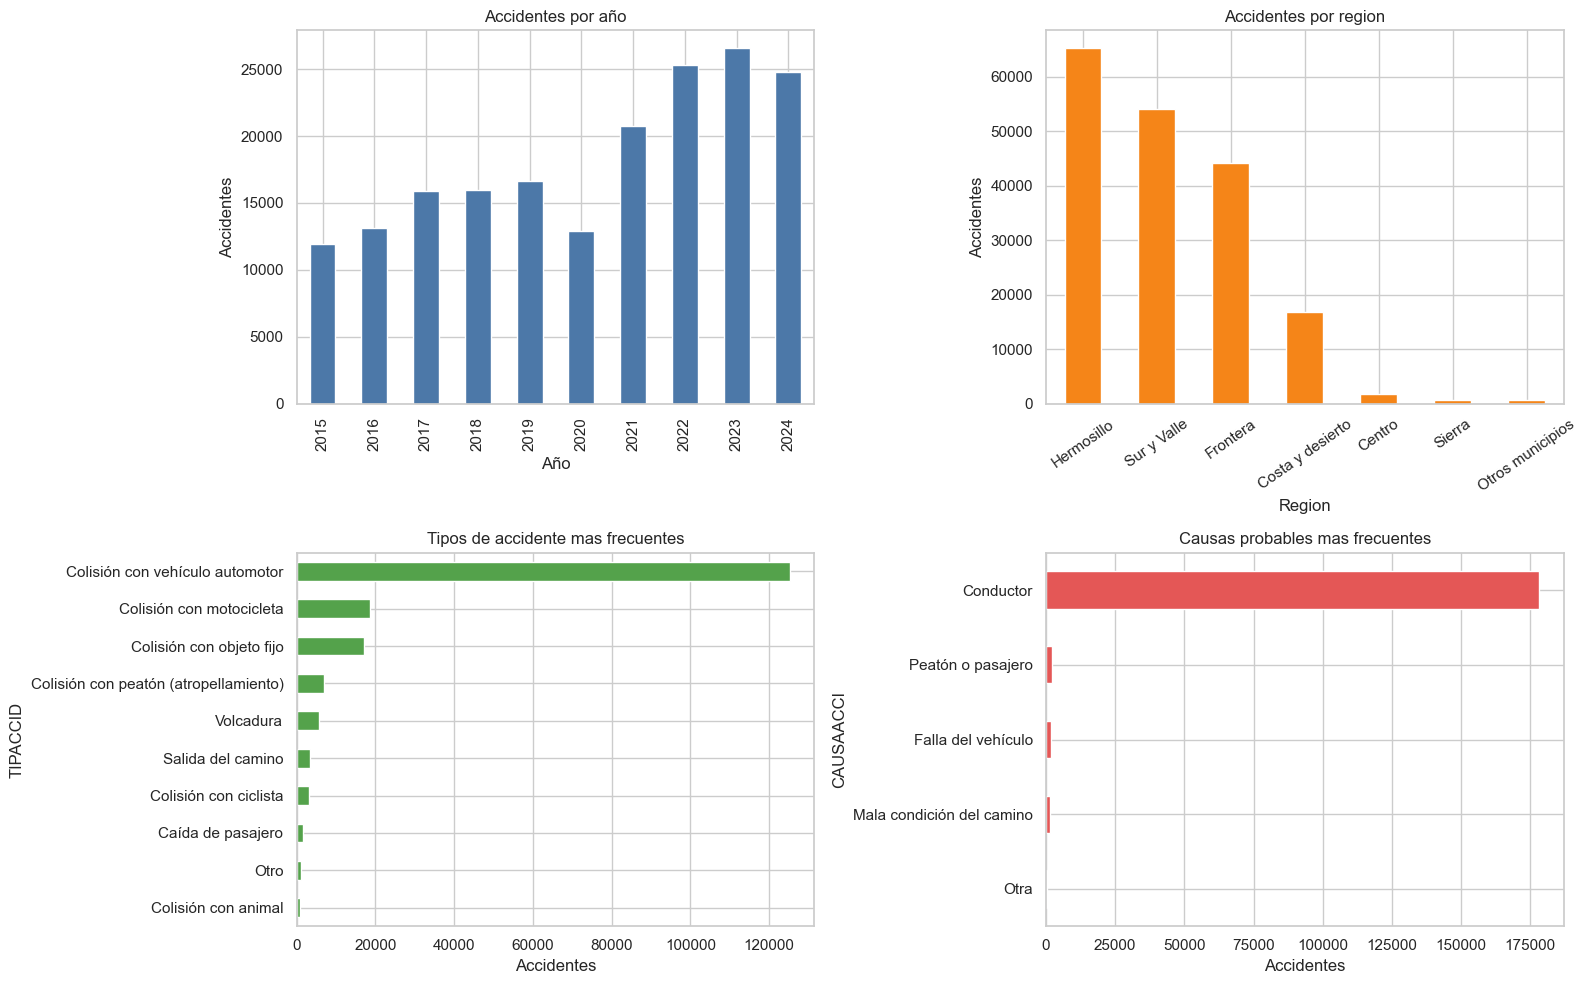

In [8]:
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

annual_counts.plot(x="ANIO", y="Accidentes", kind="bar", ax=axes[0, 0], color="#4C78A8", legend=False)
axes[0, 0].set_title("Accidentes por año")
axes[0, 0].set_xlabel("Año")
axes[0, 0].set_ylabel("Accidentes")

region_summary["accidentes"].plot(kind="bar", ax=axes[0, 1], color="#F58518")
axes[0, 1].set_title("Accidentes por region")
axes[0, 1].set_xlabel("Region")
axes[0, 1].set_ylabel("Accidentes")
axes[0, 1].tick_params(axis="x", rotation=35)

top_types = atus["TIPACCID"].value_counts().head(10).sort_values()
top_types.plot(kind="barh", ax=axes[1, 0], color="#54A24B")
axes[1, 0].set_title("Tipos de accidente mas frecuentes")
axes[1, 0].set_xlabel("Accidentes")

cause_counts = atus["CAUSAACCI"].value_counts().head(8).sort_values()
cause_counts.plot(kind="barh", ax=axes[1, 1], color="#E45756")
axes[1, 1].set_title("Causas probables mas frecuentes")
axes[1, 1].set_xlabel("Accidentes")

plt.tight_layout()
plt.show()

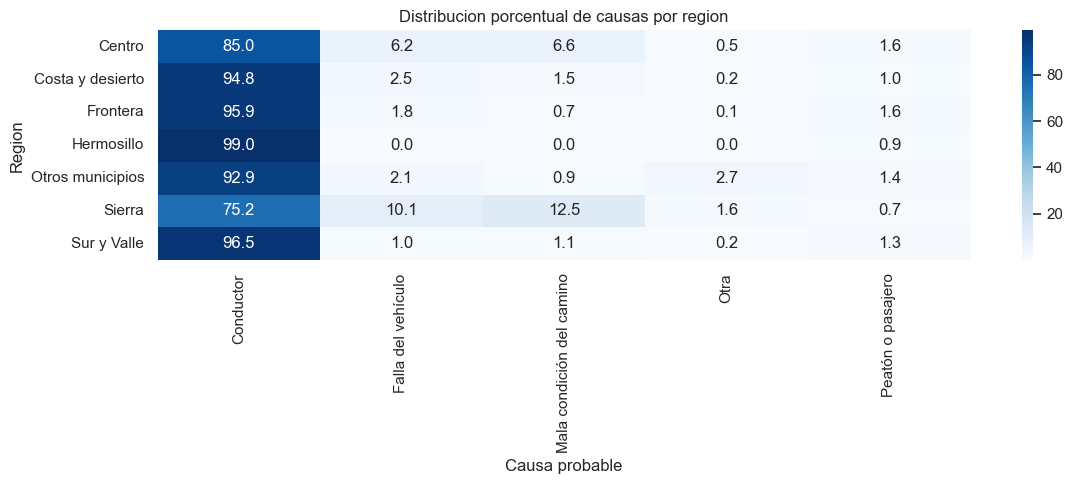

In [9]:
region_cause_pct = pd.crosstab(atus["REGION"], atus["CAUSAACCI"], normalize="index") * 100
plt.figure(figsize=(12, 5))
sns.heatmap(region_cause_pct, annot=True, fmt=".1f", cmap="Blues")
plt.title("Distribucion porcentual de causas por region")
plt.xlabel("Causa probable")
plt.ylabel("Region")
plt.tight_layout()
plt.show()

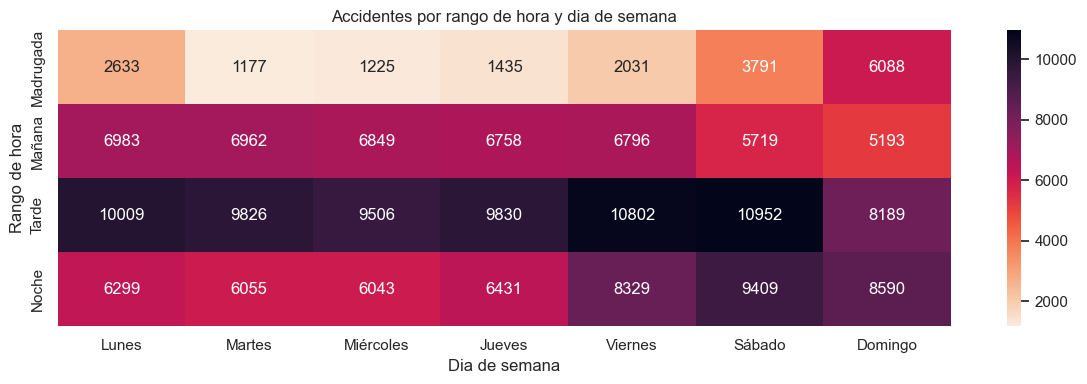

In [10]:
day_order = ["Lunes", "Martes", "Miércoles", "Jueves", "Viernes", "Sábado", "Domingo"]
hour_order = ["Madrugada", "Mañana", "Tarde", "Noche"]

heat_hour_day = pd.crosstab(atus["RANGO_HORA"], atus["DIASEMANA"])
heat_hour_day = heat_hour_day.reindex(index=hour_order, columns=day_order, fill_value=0)

plt.figure(figsize=(12, 4))
sns.heatmap(heat_hour_day, annot=True, fmt=".0f", cmap="rocket_r")
plt.title("Accidentes por rango de hora y dia de semana")
plt.xlabel("Dia de semana")
plt.ylabel("Rango de hora")
plt.tight_layout()
plt.show()


### Interpretacion de visualizaciones

El comportamiento anual muestra un aumento importante despues de 2020, con el punto mas alto del periodo en 2023. Hermosillo concentra el mayor volumen de accidentes, seguido por Sur y Valle y Frontera; sin embargo, Sierra y Centro tienen porcentajes de gravedad proporcionalmente altos. El tipo de accidente dominante es la colision con vehiculo automotor y la causa probable mas frecuente corresponde a `Conductor`. En el cruce temporal, las tardes cercanas al fin de semana destacan como franjas de interes preventivo.


## 8. Dataset preparado para siguientes etapas

Se deja listo un dataset con las variables limpias y derivadas que pueden usarse en E3 para modelado y evaluacion. En este cuaderno solo se valida su estructura.

In [11]:
prepared_columns = [
    "ANIO", "MES", "DIASEMANA", "ID_HORA", "HORA_VALIDA", "RANGO_HORA",
    "ID_ENTIDAD", "ID_MUNICIPIO", "NOM_MUNICIPIO", "REGION",
    "TIPACCID", "CAUSAACCI", "CAPAROD", "SEXO", "ALIENTO", "CINTURON",
    "EDAD_CONDUCTOR", "TOTAL_VEHICULOS", "TOTAL_HERIDOS", "TOTAL_MUERTOS", "TOTAL_VICTIMAS",
    "GRAVE_BIN", "NIVEL_GRAVEDAD", "INVOLUCRA_MOTO", "INVOLUCRA_BICI",
]
prepared = atus[[col for col in prepared_columns if col in atus.columns]].copy()
print("Filas preparadas:", f"{len(prepared):,}")
print("Columnas preparadas:", prepared.shape[1])
prepared.head()

Filas preparadas: 183,911
Columnas preparadas: 25


,ANIO,MES,DIASEMANA,ID_HORA,HORA_VALIDA,RANGO_HORA,ID_ENTIDAD,ID_MUNICIPIO,NOM_MUNICIPIO,REGION,TIPACCID,CAUSAACCI,CAPAROD,SEXO,ALIENTO,CINTURON,EDAD_CONDUCTOR,TOTAL_VEHICULOS,TOTAL_HERIDOS,TOTAL_MUERTOS,TOTAL_VICTIMAS,GRAVE_BIN,NIVEL_GRAVEDAD,INVOLUCRA_MOTO,INVOLUCRA_BICI
0,2015,1,Lunes,14,14.0,Tarde,26,002,Agua Prieta,Frontera,Colisión con vehículo automotor,Conductor,Pavimentada,Hombre,No,Se ignora,47.0,2,2,0,2,1,Con heridos,0,0
1,2015,1,Jueves,17,17.0,Tarde,26,002,Agua Prieta,Frontera,Colisión con motocicleta,Conductor,No Pavimentada,Hombre,No,Se ignora,18.0,2,4,0,4,1,Con heridos,1,0
2,2015,1,Miércoles,7,7.0,Mañana,26,002,Agua Prieta,Frontera,Colisión con vehículo automotor,Conductor,Pavimentada,Hombre,No,Se ignora,16.0,2,0,0,0,0,Solo daños,0,0
3,2015,1,Viernes,23,23.0,Noche,26,002,Agua Prieta,Frontera,Colisión con peatón (atropellamiento),Conductor,Pavimentada,Hombre,No,Se ignora,58.0,1,1,0,1,1,Con heridos,0,0
4,2015,1,Miércoles,13,13.0,Tarde,26,002,Agua Prieta,Frontera,Colisión con vehículo automotor,Conductor,Pavimentada,Hombre,No,Se ignora,18.0,2,0,0,0,0,Solo daños,0,0


## 9. Conclusiones E2

1. El dataset final conserva accidentes reales de Sonora para 2015-2024 y excluye registros `Certificado cero`.
2. Las variables derivadas quedan alineadas con el cuaderno ATUS: `REGION`, `TOTAL_HERIDOS`, `TOTAL_MUERTOS`, `TOTAL_VICTIMAS`, `GRAVE_BIN`, `NIVEL_GRAVEDAD`, `INVOLUCRA_MOTO`, `INVOLUCRA_BICI` y `RANGO_HORA`.
3. Hermosillo concentra el mayor volumen de accidentes, mientras que Sierra y Centro destacan por porcentaje de gravedad.
4. La colision con vehiculo automotor y la causa probable `Conductor` dominan el registro.
5. El dataset queda preparado para E3, donde se evaluan modelos de clasificacion, clustering jerarquico y reglas de asociacion con enfoque preventivo.
